<a href="https://colab.research.google.com/github/leandroclv/python_analise_dados_udemy/blob/main/analise_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('dados_enem_2021_BA.csv')

No Pandas podemos carregar dados diferentes formatos. Os principais são:

- CSV
- Excel
- SQL

Usando Pyspark um formato muito utilizado é o parquet. Veremos este ponto mais adiante.

De igual modo podemos escrever os arquivos em diferentes formatos(output).

Na prática o formato de dados que iremos trabalhar vai depender muito da origem dos dados, da estrutura da empresa que estaremos trabalhando, etc.

Microdados ENEM

Grupos de variáveis

  - Dados do participante
  - Dados da escola
  - Dados do local de aplicação da prova
  - Dados da prova objetiva
  - Dados da redação
  - Dados do questionário socioeconômico

Hipóteses levantadas

- Padrões especiais afetam o desempenho escolar?
- Características municipais afetam o desempenho escolar?
- Renda familiar pode afetar a nota dos alunos?
- Há diferença de desempenho entre escolas públicas e privadas?
- Qual matéria tem maior nota naquela região?

Inspeção de dados

In [3]:
#Leitura das 5 primeiras linhas
df.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,210051128744,2021,4,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927200,Ruy Barbosa,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,507.6,539.2,494.6,413.3,BAEDEBDECCEAEDDCBDEDAEECEEEDBDECBDCECBCCDABED,EEEBAABCBCDBEAEBEACEDDEDECACBDBCDACECDAECBCBD,99999ACAEEEEBDEACDACDEABCEABBDEDBAEEBDEEACDBAC...,BACEACDACBAAAEDCECABBACDCDBBA.CEABCDADADBECBE,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,80.0,20.0,380.0
1,210054173438,2021,5,F,1,2,1,2,0,2,1.0,0,2927408.0,Salvador,29.0,BA,1.0,1.0,1.0,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,210052118573,2021,3,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2903201,Barreiras,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,439.6,437.7,455.9,446.2,BCEDEACAEDCEDCBDDCCAADABADDEBEECBACDCCABBDCCA,AAEADCDCAAADCBBBAABBEAEDABCDAACDDCBDAAABAABBB,EDBEC99999DDAAEBBDCDBBAABDECAADAEACCDABCEABABE...,EBBEBDCCDDCDCBADABBBCCEABDADCBCCACBDACDCDADCE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,80.0,120.0,80.0,100.0,80.0,460.0
3,210052350230,2021,10,F,1,2,1,1,8,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2928802,Santo Estêvão,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,548.1,619.5,676.3,386.6,CCAECCADEAADDEDDEECEDDEADDDCACDEDCDCDEADBEDDE,DBBEADDCABABCECEAEBEAEDCBCAEABEEDEBBEAABCBDCD,ABCCA99999DDCACDCACABBEAAEBDAEEBDEEAADACEEDDDB...,CAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,120.0,120.0,100.0,120.0,120.0,580.0
4,210053156861,2021,9,M,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,100.0,120.0,100.0,540.0


In [4]:
#Leitura das 5 últimas linhas
df.tail()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
33735,210052371278,2021,4,M,1,3,1,2,0,2,1.0,0,2923001.0,Nova Viçosa,29.0,BA,2.0,1.0,4.0,2923001,Nova Viçosa,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,440.4,457.6,369.7,383.1,AEEAEBEDDBEBDCCBEAAADCCAEDABAEBEABDDBCCABACCE,ECEACBEDCBBAEADACEEADEDBECEDADCBDAEDADABDDCBA,99999ABAADADBBEBDCADCCECEBCEDADCEDDBDAEECABCDC...,EABAECCECDADEECDEDABCDCDABEDDCCDCBEAADDBBADAA,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,100.0,120.0,80.0,100.0,100.0,500.0
33736,210051137727,2021,3,M,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2905602,Camacan,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,566.5,628.2,573.8,629.9,CACCABEBEADBEABEEACACDEDEABAAEACEBBECCCBDCCBD,EBAACCBDDAEBBABEEEBBAEECCDEACCACBAEDBEDBCAEAB,EBAEC99999DEDADABDACBBEADECAEBADDDBEDACCDBDACA...,DAEEEEADDDCADDAABBDBDEAEDDDDBDAACDDAECCCCECBC,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,140.0,200.0,160.0,180.0,160.0,840.0
33737,210053123786,2021,4,F,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,574.6,587.1,539.2,694.6,CABCEACBEDCBDACDEACBBACCDADEAEABDACDCCCDACAAD,CABAABDBBAECDABEECBAAEDDCBADCDABDAEBBADBCCEDD,AEAAB99999DEDABCBDAECDEEBDEEBCCDAEDADABADDDACC...,DCCAECADDDCDDCBCABDCEAABDDCBCCEEEABADBCBCBCCE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,120.0,120.0,120.0,120.0,180.0,660.0
33738,210051293059,2021,6,F,1,3,1,1,2,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918407,Juazeiro,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,381.5,410.4,451.3,409.7,EDCDEBDACCECBDCBACAAEECECBEDEDCD*BEDABECDDABE,ADCBCCAACCDBDDDCDBCBCBABEDCDCAEACADBCEABCDBEA,ADCAE99999EDBCBCBCACBABDCBCDDEACBEADEDADEDDBCA...,DECBDCCECDBDBDEBEBCABDACDDCCDBAEBDDACEABDCBAA,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,160.0,100.0,140.0,140.0,620.0
33739,210053171139,2021,3,F,1,1,1,2,0,3,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2919207,Lauro de Freitas,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,430.8,442.2,510.3,476.8,EABBBDAACCBAADDDAAEABDDCDABCACBBEDCADEBDDCDCD,AADDECDAACEABBADCCABDAADCBDACCABBDBCBBBAEAABB,BCAEC99999DADCBCBDACDBCCADDBBACDBCDADBAEDDDAAB...,ACEAADEDDDCBCEBADCEDBCAEADBDEBCBCEACCADCDBBCA,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nota: os comandos `df.head()` e `df.tail()` são úteis para inspecionar e compreender o dataset

In [5]:
#Quantidade de linhas vs Quantidade de colunas
df.shape

(33740, 51)

In [6]:
#Sumário do dataset com número de valores não nulos, dtypes de cada coluna, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33740 entries, 0 to 33739
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NU_INSCRICAO            33740 non-null  int64  
 1   NU_ANO                  33740 non-null  int64  
 2   TP_FAIXA_ETARIA         33740 non-null  int64  
 3   TP_SEXO                 33740 non-null  object 
 4   TP_ESTADO_CIVIL         33740 non-null  int64  
 5   TP_COR_RACA             33740 non-null  int64  
 6   TP_NACIONALIDADE        33740 non-null  int64  
 7   TP_ST_CONCLUSAO         33740 non-null  int64  
 8   TP_ANO_CONCLUIU         33740 non-null  int64  
 9   TP_ESCOLA               33740 non-null  int64  
 10  TP_ENSINO               14636 non-null  float64
 11  IN_TREINEIRO            33740 non-null  int64  
 12  CO_MUNICIPIO_ESC        6804 non-null   float64
 13  NO_MUNICIPIO_ESC        6804 non-null   object 
 14  CO_UF_ESC               6804 non-null 

In [7]:
#Nomes das colunas
df.columns

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC',
       'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC',
       'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA',
       'SG_UF_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC',
       'TP_PRESENCA_MT', 'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC',
       'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
       'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC',
       'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH',
       'TX_GABARITO_LC', 'TX_GABARITO_MT', 'TP_STATUS_REDACAO',
       'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
       'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'],
      dtype='object')

In [8]:
#Verificar missing (dados ausentes)
((df.isna().sum() / df.shape[0]) * 100).round(2).sort_values(ascending=False)

,0
TP_DEPENDENCIA_ADM_ESC,79.83
TP_SIT_FUNC_ESC,79.83
SG_UF_ESC,79.83
NO_MUNICIPIO_ESC,79.83
CO_UF_ESC,79.83
CO_MUNICIPIO_ESC,79.83
TP_LOCALIZACAO_ESC,79.83
TP_ENSINO,56.62
CO_PROVA_MT,21.53
NU_NOTA_MT,21.53


In [9]:
#Sumário estatístico dos dados
#25%: primeiro quartil
#50%: segundo quartil (mediana)
#75%: terceiro quartil
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
NU_INSCRICAO,33740.0,2.100527e+11,981219.949219,2.100510e+11,2.100519e+11,2.100527e+11,2.100536e+11,2.100545e+11
NU_ANO,33740.0,2.021000e+03,0.000000,2.021000e+03,2.021000e+03,2.021000e+03,2.021000e+03,2.021000e+03
TP_FAIXA_ETARIA,33740.0,4.462774e+00,3.049889,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,2.000000e+01
TP_ESTADO_CIVIL,33740.0,1.014286e+00,0.319455,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
TP_COR_RACA,33740.0,2.319235e+00,0.902564,0.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,5.000000e+00
TP_NACIONALIDADE,33740.0,1.033462e+00,0.196536,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
TP_ST_CONCLUSAO,33740.0,1.710373e+00,0.689111,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00
TP_ANO_CONCLUIU,33740.0,1.590634e+00,3.226420,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.500000e+01
TP_ESCOLA,33740.0,1.499941e+00,0.587040,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00
TP_ENSINO,14636.0,1.011137e+00,0.104946,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00


In [10]:
df.index

RangeIndex(start=0, stop=33740, step=1)

In [11]:
#Quantidade de valores únicos por coluna
df.nunique().sort_values()

,0
NU_ANO,1
SG_UF_PROVA,1
CO_UF_PROVA,1
TP_SEXO,2
TP_ENSINO,2
TP_LOCALIZACAO_ESC,2
IN_TREINEIRO,2
TP_LINGUA,2
TP_PRESENCA_CN,3
TP_PRESENCA_CH,3


In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
#Seleciona uma coluna
df.TP_ESCOLA

,TP_ESCOLA
0,2
1,2
2,2
3,1
4,1
...,...
33735,2
33736,2
33737,2
33738,1


In [14]:
#Distribuição de frequência
df.TP_ESCOLA.value_counts()

,count
TP_ESCOLA,
1,18468
2,13676
3,1596


In [15]:
#Seleciona uma coluna
df['TP_ESCOLA']

,TP_ESCOLA
0,2
1,2
2,2
3,1
4,1
...,...
33735,2
33736,2
33737,2
33738,1


In [16]:
#Seleciona uma coluna
#.loc[]: seleciona colunas pelo label
#sintaxe: df.loc[linhas:colunas]
df.loc[:, 'TP_SEXO']

,TP_SEXO
0,F
1,F
2,F
3,F
4,M
...,...
33735,M
33736,M
33737,F
33738,F


In [17]:
#Selecão multiplas
df[['TP_SEXO', 'TP_ESCOLA']]

,TP_SEXO,TP_ESCOLA
0,F,2
1,F,2
2,F,2
3,F,1
4,M,1
...,...,...
33735,M,2
33736,M,2
33737,F,2
33738,F,1


In [18]:
#Seleciona múltiplas colunas com .loc
df.loc[:,['TP_SEXO', 'TP_ESCOLA']]

,TP_SEXO,TP_ESCOLA
0,F,2
1,F,2
2,F,2
3,F,1
4,M,1
...,...,...
33735,M,2
33736,M,2
33737,F,2
33738,F,1


In [19]:
#.iloc[]: Seleciona colunas pela posição
df.iloc[0:5, 0]

,NU_INSCRICAO
0,210051128744
1,210054173438
2,210052118573
3,210052350230
4,210053156861


Com a função `.select_dtypes()` podemos selecionar colunas de acordo com seu dtype (int, float, bool, etc.). Em várias situações isso pode ser útil, dentre outras coisas para aplicarmos rotinas específicas deacordo com o dtype ou ainda separar as colunas em qualitativas e quantitativas

In [20]:
#Seleciona colunas numéricas
df.select_dtypes(include=[int, float])

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,CO_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,CO_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,210051128744,2021,4,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,2927200,29,1,1,1,1,909.0,881.0,892.0,899.0,507.6,539.2,494.6,413.3,1,1.0,80.0,120.0,80.0,80.0,20.0,380.0
1,210054173438,2021,5,1,2,1,2,0,2,1.0,0,2927408.0,29.0,1.0,1.0,1.0,2927408,29,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,210052118573,2021,3,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,2903201,29,1,1,1,1,912.0,882.0,891.0,901.0,439.6,437.7,455.9,446.2,0,1.0,80.0,120.0,80.0,100.0,80.0,460.0
3,210052350230,2021,10,1,2,1,1,8,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2928802,29,1,1,1,1,911.0,880.0,890.0,902.0,548.1,619.5,676.3,386.6,0,1.0,120.0,120.0,100.0,120.0,120.0,580.0
4,210053156861,2021,9,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2910800,29,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,0,1.0,100.0,120.0,100.0,120.0,100.0,540.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33735,210052371278,2021,4,1,3,1,2,0,2,1.0,0,2923001.0,29.0,2.0,1.0,4.0,2923001,29,1,1,1,1,909.0,881.0,892.0,899.0,440.4,457.6,369.7,383.1,1,1.0,100.0,120.0,80.0,100.0,100.0,500.0
33736,210051137727,2021,3,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,2905602,29,1,1,1,1,912.0,882.0,891.0,901.0,566.5,628.2,573.8,629.9,0,1.0,140.0,200.0,160.0,180.0,160.0,840.0
33737,210053123786,2021,4,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,2927408,29,1,1,1,1,912.0,882.0,891.0,901.0,574.6,587.1,539.2,694.6,0,1.0,120.0,120.0,120.0,120.0,180.0,660.0
33738,210051293059,2021,6,1,3,1,1,2,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2918407,29,1,1,1,1,909.0,881.0,892.0,899.0,381.5,410.4,451.3,409.7,0,1.0,80.0,160.0,100.0,140.0,140.0,620.0


In [21]:
#Seleciona colunas str
#df.select_dtypes(exclude=[int, float])
df.select_dtypes(include=object)

,TP_SEXO,NO_MUNICIPIO_ESC,SG_UF_ESC,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT
0,F,NaN,NaN,Ruy Barbosa,BA,BAEDEBDECCEAEDDCBDEDAEECEEEDBDECBDCECBCCDABED,EEEBAABCBCDBEAEBEACEDDEDECACBDBCDACECDAECBCBD,99999ACAEEEEBDEACDACDEABCEABBDEDBAEEBDEEACDBAC...,BACEACDACBAAAEDCECABBACDCDBBA.CEABCDADADBECBE,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB
1,F,Salvador,BA,Salvador,BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,NaN,NaN,Barreiras,BA,BCEDEACAEDCEDCBDDCCAADABADDEBEECBACDCCABBDCCA,AAEADCDCAAADCBBBAABBEAEDABCDAACDDCBDAAABAABBB,EDBEC99999DDAAEBBDCDBBAABDECAADAEACCDABCEABABE...,EBBEBDCCDDCDCBADABBBCCEABDADCBCCACBDACDCDADCE,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE
3,F,NaN,NaN,Santo Estêvão,BA,CCAECCADEAADDEDDEECEDDEADDDCACDEDCDCDEADBEDDE,DBBEADDCABABCECEAEBEAEDCBCAEABEEDEBBEAABCBDCD,ABCCA99999DDCACDCACABBEAAEBDAEEBDEEAADACEEDDDB...,CAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA
4,M,NaN,NaN,Feira de Santana,BA,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33735,M,Nova Viçosa,BA,Nova Viçosa,BA,AEEAEBEDDBEBDCCBEAAADCCAEDABAEBEABDDBCCABACCE,ECEACBEDCBBAEADACEEADEDBECEDADCBDAEDADABDDCBA,99999ABAADADBBEBDCADCCECEBCEDADCEDDBDAEECABCDC...,EABAECCECDADEECDEDABCDCDABEDDCCDCBEAADDBBADAA,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB
33736,M,NaN,NaN,Camacan,BA,CACCABEBEADBEABEEACACDEDEABAAEACEBBECCCBDCCBD,EBAACCBDDAEBBABEEEBBAEECCDEACCACBAEDBEDBCAEAB,EBAEC99999DEDADABDACBBEADECAEBADDDBEDACCDBDACA...,DAEEEEADDDCADDAABBDBDEAEDDDDBDAACDDAECCCCECBC,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE
33737,F,NaN,NaN,Salvador,BA,CABCEACBEDCBDACDEACBBACCDADEAEABDACDCCCDACAAD,CABAABDBBAECDABEECBAAEDDCBADCDABDAEBBADBCCEDD,AEAAB99999DEDABCBDAECDEEBDEEBCCDAEDADABADDDACC...,DCCAECADDDCDDCBCABDCEAABDDCBCCEEEABADBCBCBCCE,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE
33738,F,NaN,NaN,Juazeiro,BA,EDCDEBDACCECBDCBACAAEECECBEDEDCD*BEDABECDDABE,ADCBCCAACCDBDDDCDBCBCBABEDCDCAEACADBCEABCDBEA,ADCAE99999EDBCBCBCACBABDCBCDDEACBEADEDADEDDBCA...,DECBDCCECDBDBDEBEBCABDACDDCCDBAEBDDACEABDCBAA,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB


In [22]:
cat_cols = df.select_dtypes(include=object).columns.tolist()
cat_cols

['TP_SEXO',
 'NO_MUNICIPIO_ESC',
 'SG_UF_ESC',
 'NO_MUNICIPIO_PROVA',
 'SG_UF_PROVA',
 'TX_RESPOSTAS_CN',
 'TX_RESPOSTAS_CH',
 'TX_RESPOSTAS_LC',
 'TX_RESPOSTAS_MT',
 'TX_GABARITO_CN',
 'TX_GABARITO_CH',
 'TX_GABARITO_LC',
 'TX_GABARITO_MT']

In [23]:
num_cols = df.select_dtypes(include=[int, float]).columns.tolist()
num_cols

['NU_INSCRICAO',
 'NU_ANO',
 'TP_FAIXA_ETARIA',
 'TP_ESTADO_CIVIL',
 'TP_COR_RACA',
 'TP_NACIONALIDADE',
 'TP_ST_CONCLUSAO',
 'TP_ANO_CONCLUIU',
 'TP_ESCOLA',
 'TP_ENSINO',
 'IN_TREINEIRO',
 'CO_MUNICIPIO_ESC',
 'CO_UF_ESC',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_SIT_FUNC_ESC',
 'CO_MUNICIPIO_PROVA',
 'CO_UF_PROVA',
 'TP_PRESENCA_CN',
 'TP_PRESENCA_CH',
 'TP_PRESENCA_LC',
 'TP_PRESENCA_MT',
 'CO_PROVA_CN',
 'CO_PROVA_CH',
 'CO_PROVA_LC',
 'CO_PROVA_MT',
 'NU_NOTA_CN',
 'NU_NOTA_CH',
 'NU_NOTA_LC',
 'NU_NOTA_MT',
 'TP_LINGUA',
 'TP_STATUS_REDACAO',
 'NU_NOTA_COMP1',
 'NU_NOTA_COMP2',
 'NU_NOTA_COMP3',
 'NU_NOTA_COMP4',
 'NU_NOTA_COMP5',
 'NU_NOTA_REDACAO']

Filtro

Existe diferença na nota de matemática entre alunos de escola pública e privada?

In [24]:
#Alunos colégio público
df.query('TP_ESCOLA == 2').NU_NOTA_MT.agg([np.mean, np.median])

/tmp/ipykernel_1916/3707071764.py:2: FutureWarning: The provided callable <function mean at 0x7c52301dff60> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.query('TP_ESCOLA == 2').NU_NOTA_MT.agg([np.mean, np.median])
/tmp/ipykernel_1916/3707071764.py:2: FutureWarning: The provided callable <function median at 0x7c522fbcb380> is currently using Series.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.query('TP_ESCOLA == 2').NU_NOTA_MT.agg([np.mean, np.median])


,NU_NOTA_MT
mean,492.173686
median,474.700000


In [25]:
#Alunos de escola privada
df.query('TP_ESCOLA == 3').NU_NOTA_MT.agg([np.mean, np.median])

/tmp/ipykernel_1916/2854653440.py:2: FutureWarning: The provided callable <function mean at 0x7c52301dff60> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.query('TP_ESCOLA == 3').NU_NOTA_MT.agg([np.mean, np.median])
/tmp/ipykernel_1916/2854653440.py:2: FutureWarning: The provided callable <function median at 0x7c522fbcb380> is currently using Series.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.query('TP_ESCOLA == 3').NU_NOTA_MT.agg([np.mean, np.median])


,NU_NOTA_MT
mean,589.074435
median,591.900000


In [26]:
#Validando a nossa consulta
#.unique(): retorna os valores únicos de uma determinada coluna
df.query('TP_SEXO == "M"')['TP_SEXO'].unique()

array(['M'], dtype=object)

In [27]:
#1 condição
df.query('TP_SEXO == "M"').sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
6913,210051971587,2021,3,M,1,1,1,2,0,2,1.0,0,2925105.0,Poções,29.0,BA,2.0,1.0,1.0,2925105,Poções,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,365.4,469.6,495.8,483.2,EDCAADDBCBAABEACDAAACBDBDDBACBCDCDAACBCEEACCE,DAACAADBABDAECEDEADECCBEACABAABEEADACBABEEAAA,DEAEB99999DCBAEDAABDBCAADAAEABEADCABBDECADADDD...,AECCBDACEDEECBAACCDABBEEABEBDDACBEAEDECCBABDE,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,140.0,40.0,40.0,120.0,40.0,380.0
5972,210051932537,2021,4,M,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19772,210054191309,2021,5,M,1,1,1,1,2,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2921708,Morro do Chapéu,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,437.8,464.6,565.9,428.8,ECBADEAEDBEEECCED*AACEDEBEBDDACCEAAEECBCBADAC,BCEDECAABCECEAACDACDDBDDAEBBBCAAABDBEECDEBCDD,99999AAACACDABCBACBDDABDCDCBADABBEDDCBCAECCAAB...,DECDEEBEDADAABBBEBAAEBCBBADACCEEEACBDBADACADA,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,120.0,120.0,120.0,120.0,140.0,620.0
18363,210053266713,2021,3,M,1,2,1,2,0,2,1.0,0,2918704.0,Lafaiete Coutinho,29.0,BA,2.0,1.0,1.0,2918001,Jequié,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,470.9,456.3,488.5,546.6,DAABCABCEDCDCDEEADECCEDEAACBAEDCDDEBEDCCBCECB,DBADACCBEAECEEBEEEBBAABAADEDEDCDEBEABADBEBABE,AADDE99999DEEADEDDAEDDEEDECBDEDBBBEDECACDDADAE...,CDCDEBEDBDBCCDBACBACADAEEABCCCBADBAAABEDBBCEB,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,160.0,120.0,120.0,120.0,120.0,640.0
4629,210052706671,2021,5,M,1,3,1,1,1,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2906808,Cansanção,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
#VAlidando a nossa consulta
#.unique(): retorna os valores únicos de uma determinada coluna
df.query('TP_SEXO == "M"')['TP_SEXO'].unique()

array(['M'], dtype=object)

Agora vamos retornar um subset com os alunos do sexo Masculino que sejam treinados. Neste caso, usaremos o operador & (and).

In [29]:
df.query("(TP_SEXO == 'M')&(IN_TREINEIRO == 1)").sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
19521,210051603054,2021,3,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2924009,Paulo Afonso,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,407.8,488.3,447.8,432.7,BEDCDACCAEBDBCCAEDBABBCAEDDCEBAECEDDDCCEBDACB,BDEECBEACADACBEECEEABB*ABCCADEDCAEADEB..DDEAB,99999BDABBCDDDAEDADCDAEBDBCBC*DAEAEDBDAAAE.DCE...,DCAACEEDCEBABDEABECDBDCEAAECAAAECDAECEBADBDCD,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,100.0,40.0,420.0
7179,210052676916,2021,2,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2908408,Conceição do Coité,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,434.6,434.3,451.0,613.8,DABCCAEECDBDAACBBACCBECCABEAEBAABCEAACDBBBDEB,ECECBAACADDBBBDBDBBCDBADCCCDDCABABDDABECCEADD,DDBAB99999DDBDDBBDDCACDBACABAECCACCDEEAAACAEBB...,EECEDCEDACECCEEABBBEBCACDAADCAACBDAEBCABADDCB,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,120.0,120.0,120.0,120.0,60.0,540.0
31416,210052197284,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,506.8,673.6,632.2,702.0,AABDDECEBDCBDAAEEBEBCBCDAABDAABADAABCCCDDCCED,ECAAEABBEAEBDABEECBAADEDBBADCDADBCBDBEBBCAEDB,ACABC99999DEBBCCBAACBEEADDCADBEDDCACDACCDBDCCE...,DCCAEADCDDEADEACDBCABCADCCEBEBEACDEBCBBBDEDEE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,140.0,200.0,140.0,160.0,160.0,800.0
2380,210051892363,2021,1,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2933000,Valente,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,388.3,399.9,405.7,474.9,CCAEBDBACAADBCDBDAEACADCDD*AABABACBDBBADCDDBD,CCDDADACBDABCDABADAECEBEEAECBCBBDADDDDEABDBDE,CACEA99999DBCAABAADBDCACDCDACDBECCBACEEACDEADE...,DACBDECECCCBCCDBDEABCADECDBECCCCCBCADEBBCDCCE,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,6.0,0.0,0.0,0.0,0.0,0.0,0.0
2091,210051306842,2021,4,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2906204,Canarana,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,554.3,570.3,555.3,578.6,CCDBBECAEDECBEDADCCCCCEABCBCBCDCDCADBCBCCECBC,DBBAADBEABBBAECDEDAAAEAEACBEADDEBEDEEABDCBDDC,AEBEA99999CAEACDCBDEBBEEAEBEEDEADCEBDEECEDDDBA...,ACCDEBDBCEDDECCCCCCCCEEBCACCCCDDEABDACCADCBEB,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,160.0,200.0,160.0,160.0,200.0,880.0


Agora vamos retornar um subset com os alunos do sexo Masculino que sejam treinados. Neste caso, usaremos o operador | (or).

In [30]:
df.query("(TP_SEXO == 'M')|(IN_TREINEIRO == 1)").sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
10212,210051917249,2021,2,F,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2906303,Canavieiras,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,425.3,463.4,372.6,522.5,BEBAECECDEAAEACCAAECBECEBBDDECCBCBEEECACBBBBE,BEABEDCCDACABABAECEBCEACADDDBDEBACAEBEEADBDEA,DDCEA99999EEBDCDECDBCBDACBEACBBACBADCEBBEECAAB...,BACEEBDDBECACEDCDAEBEEBCCBEAAEBBEDCBAECDBDBAE,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,100.0,140.0,100.0,100.0,0.0,440.0
10109,210051385865,2021,16,M,1,4,1,1,15,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9494,210053328605,2021,4,F,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2923803,Paripiranga,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,423.2,547.3,459.5,680.7,AAEECCABBADAACDADACBEDBABAACEBAABCBEDDCBCCEEC,EEDCDAABBABBABEACADABCCACAECBEADBCABDAACADACA,ABDCC99999AEEDEDEABBCDACDEBCEADBAAEAEDAADEAAAB...,DDCABDCEDBDEDCBEBAAEECEAECDDDBCCADECABEBACCEC,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,120.0,120.0,120.0,120.0,600.0
29828,210053701318,2021,1,F,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2923605,Paramirim,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,393.3,496.6,464.1,381.7,EAEDEEBACECCDDBCAACEDACABDDEBEECACBECCBDDECCD,AEEACBEAAABBBABBAEABACBBADBCCDAEBDADCBDBABECE,99999CEAACDDBCCABDAABAEBADCBDAABAEDAEBEBACBECB...,EDEEEADCCBACDDBABEEEBDDAABCDECBCCBCDCDEEEBEBD,1,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,100.0,120.0,80.0,100.0,40.0,440.0
17916,210051871291,2021,2,F,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2926301,Riachão do Jacuípe,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,428.5,477.4,467.9,433.9,CDCBCBDCDACEBEBEACBEDBCDCBDAEBDACCAACEABABBCB,BADBECDBAEEDDCADABBCAEDBAEAEADEBDABEDCBBDDECC,99999CAADCBDCADDBCCDACDBEEBBCADDBEEBBDCEBADDAC...,DADBEABEEDAEDCBDBDEDCBDDBEEADBAECCABDCECBEBDC,1,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,160.0,100.0,120.0,140.0,120.0,640.0


In [31]:
#Criando uma máscara booleana
mask = df.TP_SEXO == 'M'

In [32]:
df[mask]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
4,210053156861,2021,9,M,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,100.0,120.0,100.0,540.0
5,210053085526,2021,3,M,1,1,1,2,0,2,1.0,0,2932606.0,Urandi,29.0,BA,2.0,1.0,1.0,2932606,Urandi,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,414.6,410.1,386.7,423.0,CBCAEDDBBCBABADAABECACCEBDEABCCAECEECCDBCBDCB,BACDABADEBACEDCACDADBCBDBDBECADBEDAEBDCAEBDCA,BAEAB99999CACBABEBADECADCEDCBCADABDEDBDCABCACB...,EACDCADDDCDBADABACEDEDCECBDCCBEAACEADEAECCCEC,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,180.0,140.0,160.0,100.0,700.0
7,210053790986,2021,1,M,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2907202,Casa Nova,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,590.9,659.7,593.6,586.8,BADCBEEBECDDEABAEDEBCDCCDABBBEBBDDACCCADBEACE,EBBBEADACABBBADEECBAAEDDBBADCDADBCADDEBBCCEAB,ACBAB99999DCEADCADACBDEAEDDABDADCBBBDABCDDDECB...,DDEBEEEDDDCAEEBACBEAADDDCCEDEEBABEECEBEEBCAAC,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,160.0,180.0,160.0,200.0,200.0,900.0
9,210054171092,2021,4,M,1,2,1,1,1,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,210052237624,2021,5,M,1,2,1,2,0,2,1.0,0,2910503.0,Entre Rios,29.0,BA,2.0,1.0,1.0,2910503,Entre Rios,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,594.4,572.8,536.6,469.6,DCADABEEABDAEDABADCABEACABDAEBECBBBDCCCDBCBCD,BEECCABABABBEAEACBADCAEBEDAABAEAEADCCCAAEEBAA,ABBAB99999ADDBAABABCBBBACADAEDBBCCEEEBEAACCDBE...,DABEACCEACAACBBABBBACCAACBBAAECBBCBEBCCCBABBD,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,100.0,100.0,80.0,80.0,80.0,440.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33719,210053296820,2021,3,M,1,2,1,1,1,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918407,Juazeiro,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,421.7,574.4,529.3,464.2,DCDBCEDEBCBBABBDABDCDAEDACACBEDABDBCCCDCDEBEC,DAEDAAEBCAEBBBBCECBBABEAAEEDBDBAABECDEBECAEBE,AAACC99999ECDABDBDAABAEABEBEBCADDDACCDECDCADCE...,CDECEABCDBCDBDBEDEDAAEBCDEDEBAEEEDBBADCBCBBBC,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,100.0,140.0,120.0,120.0,160.0,640.0
33724,

In [33]:
df.loc[mask].sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
19222,210052890370,2021,4,M,0,4,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7480,210051057938,2021,2,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2911204,Gandu,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,448.2,579.5,438.7,435.8,BADEDCBADDBAEEACEDDCAECCDBEAECEDDEDACCAACCDEE,BDACCABDBAEBEADCAAACBDEDABDABDDAAAEDBBABBDBBA,99999ADCCCDAABDEBEDCDBDBAEECCCECADAEBEEAACDCBE...,BDAEEBEEBEBAEEEEECCBDDACAABDACDEACCBDBBBDBACD,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,120.0,100.0,500.0
5233,210054146733,2021,11,M,1,3,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2932200,Ubaitaba,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14317,210053265931,2021,6,M,1,1,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,1011.0,1001.0,1005.0,1007.0,409.2,576.1,428.1,623.0,ADDDBBEEADBBCCABCAECAECDBBDDCCEEEBACEBAADDDAC,AEACCABBAACBCAACDACEDDADBDCDDCBCAAEDAEADCECDA,99999AACDCCDBBEDEEECACEDAECDDEBADCADDADEABEBDA...,DADEDACDDCDACEECDBBDBDAEDDEBBDAEABCDCCCEADADB,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,120.0,120.0,120.0,120.0,100.0,580.0
3772,210054206880,2021,2,M,1,3,2,2,0,2,1.0,0,2902500.0,Baianópolis,29.0,BA,2.0,1.0,1.0,2903201,Barreiras,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,402.5,462.8,402.9,499.9,ECCDCCA*CBDAEEBDBCBAD*CCABEEEEDBBACACDADCADCD,CBABACEABACBDA.BEBBACADBAABDDCABEBDBBDDACAAEC,99999DCEADEDBACADEAABEBEACCEECDBADEADAADEDCCBA...,BAEAEBECCEECCDAADDEBCBAEACBAEBACCDEAEBABCEBDB,1,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,160.0,180.0,140.0,200.0,180.0,860.0


In [34]:
df.loc[(df.TP_SEXO == 'M') & (df.IN_TREINEIRO == 1)].sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
6579,210051966384,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2911709,Guanambi,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,582.0,616.0,551.0,554.4,ABCECCCBBCCDBBDCDCBAAAEEDDCCADDBEEDBDBCDEDBBE,EEBCDADBCEEBABBAEBBABEEDCCECBEEEAACADEBBAEDBB,EEBBB99999BDCDEBEEEDBADAEDBDBDABDCAADCACDACACC...,DDCAACBEDBDAEDBACAABCECDABDECBEAACEBDBADBCDCA,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,120.0,120.0,120.0,120.0,600.0
10550,210052638298,2021,3,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2926301,Riachão do Jacuípe,29,BA,2,1,1,2,NaN,882.0,891.0,NaN,NaN,411.8,454.8,NaN,NaN,DBDEDACAADCEADBEBCDAEBEDBACAEACBDBAEDBDBEBDBD,AECAC99999CBEAACABADDBAEBAAADBBAEADDABCABDABEA...,NaN,0,NaN,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,NaN,6.0,0.0,0.0,0.0,0.0,0.0,0.0
25884,210051975898,2021,5,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2906006,Campo Formoso,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,358.4,405.8,420.8,386.0,CEDCAACDDDDBADEBCDCACACDEEDDABABADAEEAEEDCCAA,BAABABDECCDACAECDACABCCACCEADDCEADDBAAACEEAAE,AEAEC99999AAAADADBAEACDACACBDCCBBABEBBDEECDCAA...,ADDBADDCEAEAECCDBBADABAEBDBDCADDBEDCACEBABACB,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,40.0,40.0,80.0,40.0,280.0
779,210054153592,2021,2,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2905008,Caculé,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,507.7,604.7,560.9,665.2,BDECCBDABCCEBDEABDBDADEECDBECBABEAEBCACDBDACD,BDCCDCADCBDDEBAADCBABEEBCAEABECADADABCABCEECB,BAADB99999BBCDEADCDABADAEABECADBDCBADCBDBAEACE...,BDCACDDCAEBBCDBEADACBAEDEDAEBBCACBDCADECACEBE,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,140.0,200.0,120.0,160.0,160.0,780.0
32361,210051742706,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2905008,Caculé,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,518.3,547.7,601.7,533.3,ABAECBADBCDCBBDBBBBEABADAADAAAEBEDAACCECCCDAA,BDCCDBBBBDCDEBAACAEABDECCACCBBABEDDADEEBAABDA,CAAAC99999BDDDEADEBDBBADCABBDEDCCCBADBBDDADACB...,DBCAEEBBBCDBCACACEAEDDEDADECABCAADECBDADEBBEB,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,120.0,140.0,120.0,100.0,600.0


Uma forma alternativa:

In [35]:
condition_1 = df.TP_SEXO == 'M'
condition_2 = df.IN_TREINEIRO == 1
df.loc[(condition_1) & (condition_2)]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
69,210053707047,2021,1,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2902104,Araci,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,521.7,566.7,569.5,702.3,DDD*CEEDECBBEACBAACABEDCEACEEEABCACCCCBDBEDED,DDEDEBCAEDCCBBBEACABAEEADBABCDABBDECBEBACAEAC,ABACC99999DAEADCBDACDDCACDDACADAAEDCDACDDCDACE...,CCEDEBCCDDCDBEBCCBCAEAABDAEEDCEADDABDBABCDACB,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,160.0,200.0,160.0,200.0,180.0,900.0
113,210051127853,2021,1,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2932903,Valença,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,494.4,408.4,504.1,483.3,CBECBCEBEDBADCEBADABBAACBDBAEBBEDCBDAEBDBEBCE,ECEBADDABBACCCBDADEECACABCACBADCBAEACCCAABBCA,BACBA99999CECACBBACCBBEDAEEBADEBEEBACDACACEACD...,AACBCACDDBABCDCBDADBDCEDDBBDACECBDDCADCECBDCA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,120.0,120.0,120.0,140.0,160.0,660.0
151,210053634740,2021,5,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,210052073811,2021,1,M,1,2,2,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2911204,Gandu,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204,210053593141,2021,2,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,541.6,646.9,510.6,601.0,AEDDABDEADBDEBCAADDCBBCCDCBADECACCDDCEADBCACA,BCECCAEABABCEAEBAACAEDEBBEBABCBBAEEBBEDECBBBA,DACAC99999ACBDDEBEEBCCBBCEAAADAAADAECDEBADCBAA...,CADEEBDDDCBBCBBBBEDDCDAABDBABBEDCCCDDDDBDBCAC,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,140.0,40.0,40.0,140.0,40.0,400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33673,210052001933,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918001,Jequié,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,528.6,526.6,495.7,614.3,CCAEDDCEEBCAEACEBAEEBCDCBDAECBABCCDABCADAE*CB,DBBAAACBCCDBCEBACBBAAEEBAAAABDDEDEBABCBABAAAC,99999CAABDBDEADBBBCDBECAEDADAABADEBABEAAEDBDCD...,ACCABBAEDADECACBDAECCAEDECBDABDCCABCEDDEDDCCA,1,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,120.0,160.0,120.0,120.0,80.0,600.0
33695,210051752287,2021,4,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2932903,Valença,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,426.7,544.8,528.2,444.9,DADACACEDBBAECDBACBACBBEEDADAECEADEDEABCEAAAB,ADECBADBEBEBEBAABAEABECCAACBCAEABACABBABABEBA,AAAED99999CDBDEABBDCBDEACBBBEEDDBDBACCADDAAADB...,DABCECCCEBBACBCBDACDBADACCDDABDEACECABADBAABA,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAE

Negação

Podemos usar o operador `~` para negar uma determinada condição:

In [36]:
df[~(df.NO_MUNICIPIO_PROVA.isin(['Salvador']))]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,210051128744,2021,4,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927200,Ruy Barbosa,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,507.6,539.2,494.6,413.3,BAEDEBDECCEAEDDCBDEDAEECEEEDBDECBDCECBCCDABED,EEEBAABCBCDBEAEBEACEDDEDECACBDBCDACECDAECBCBD,99999ACAEEEEBDEACDACDEABCEABBDEDBAEEBDEEACDBAC...,BACEACDACBAAAEDCECABBACDCDBBA.CEABCDADADBECBE,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,80.0,20.0,380.0
2,210052118573,2021,3,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2903201,Barreiras,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,439.6,437.7,455.9,446.2,BCEDEACAEDCEDCBDDCCAADABADDEBEECBACDCCABBDCCA,AAEADCDCAAADCBBBAABBEAEDABCDAACDDCBDAAABAABBB,EDBEC99999DDAAEBBDCDBBAABDECAADAEACCDABCEABABE...,EBBEBDCCDDCDCBADABBBCCEABDADCBCCACBDACDCDADCE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,80.0,120.0,80.0,100.0,80.0,460.0
3,210052350230,2021,10,F,1,2,1,1,8,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2928802,Santo Estêvão,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,548.1,619.5,676.3,386.6,CCAECCADEAADDEDDEECEDDEADDDCACDEDCDCDEADBEDDE,DBBEADDCABABCECEAEBEAEDCBCAEABEEDEBBEAABCBDCD,ABCCA99999DDCACDCACABBEAAEBDAEEBDEEAADACEEDDDB...,CAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,120.0,120.0,100.0,120.0,120.0,580.0
4,210053156861,2021,9,M,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,100.0,120.0,100.0,540.0
5,210053085526,2021,3,M,1,1,1,2,0,2,1.0,0,2932606.0,Urandi,29.0,BA,2.0,1.0,1.0,2932606,Urandi,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,414.6,410.1,386.7,423.0,CBCAEDDBBCBABADAABECACCEBDEABCCAECEECCDBCBDCB,BACDABADEBACEDCACDADBCBDBDBECADBEDAEBDCAEBDCA,BAEAB99999CACBABEBADECADCEDCBCADABDEDBDCABCACB...,EACDCADDDCDBADABACEDEDCECBDCCBEAACEADEAECCCEC,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,180.0,140.0,160.0,100.0,700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33734,210051523668,2021,3,F,1,3,1,2,0,2,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918100,Jeremoabo,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,386.8,443.1,382.1,392.6,BDEDACDEAECACEBABABDDE*EAAAAEDCEACEDEECCEABBD,ADAEDDABECEDCDDC

Visualização dos dados

In [37]:
provas = df.columns[(df.columns.str.contains('NOTA')) & (~df.columns.str.contains('COMP'))].tolist()
provas

['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

Utilizando uma sintaxe simples de biblioteca Pandas conseguimos gerar análises gráficas rapidamente. Podemos fazer os seguintes tipos de gráficos:

- Barras
- Pizza
- Linha
- Histograma
- Boxplot
- Densidade
- Área
- Dispersão

<Axes: xlabel='TP_SEXO'>

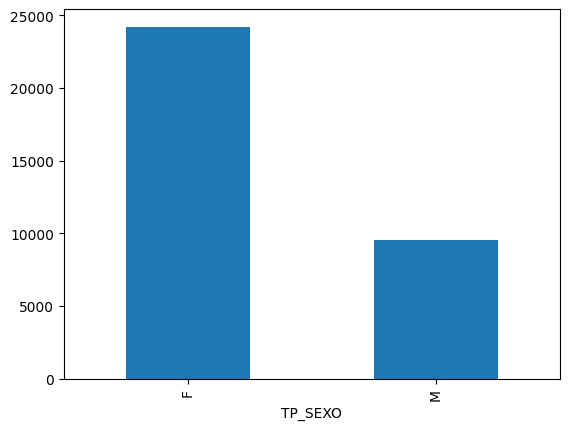

In [38]:
df.TP_SEXO.value_counts().plot(kind='bar')

Text(0.5, 1.0, 'Tipo de escola dos participantes no ENEM 2021')

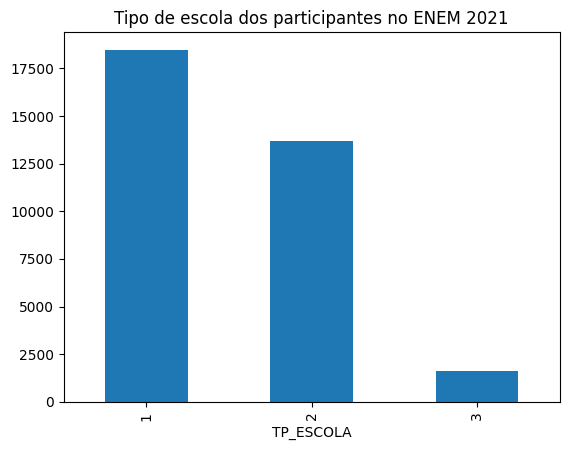

In [39]:
df.TP_ESCOLA.value_counts().plot(kind='bar')
plt.title('Tipo de escola dos participantes no ENEM 2021')

Melhorando um pouco o plot

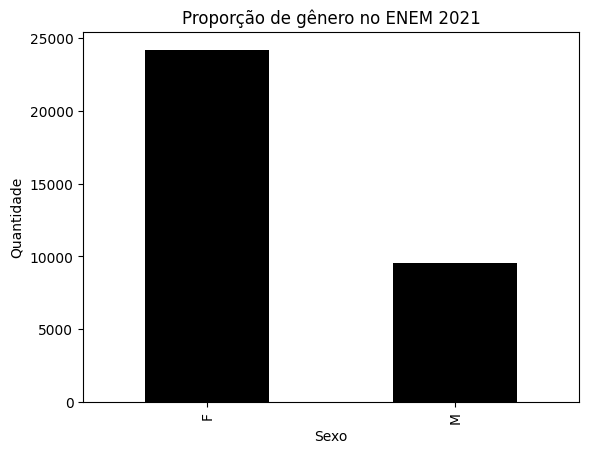

In [40]:
#Gráfico de barras
df.TP_SEXO.value_counts().plot(kind='bar', color='black')

#Titulo
plt.title('Proporção de gênero no ENEM 2021')

#label dos eixos X e Y
plt.xlabel('Sexo')
plt.ylabel('Quantidade')

plt.show()
#plt.xlabel('Sexo'); plt.ylabel('Quantidade);plt.show()

<Axes: title={'center': 'Municípios baianos com maior quantidade de inscritos no ENEM de 2021'}, xlabel='Quantidade', ylabel='Município'>

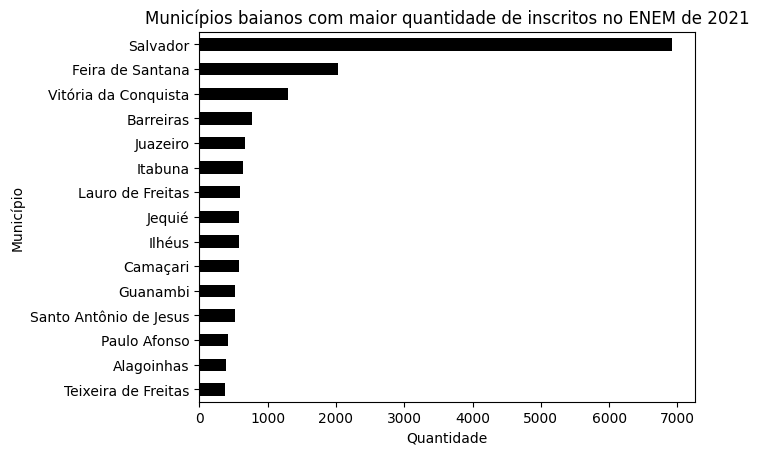

In [57]:
(df.NO_MUNICIPIO_PROVA
 .value_counts()
 .reset_index()
 .rename(columns = {'NO_MUNICIPIO_PROVA': 'Município', 'count':'Quantidade'})
 .set_index('Município')
 .nlargest(n=15, columns = 'Quantidade')
 .sort_values(by='Quantidade',ascending=True)
 .plot(
        kind='barh',
        color='black',
        legend=False,
        xlabel='Quantidade',
        title = 'Municípios baianos com maior quantidade de inscritos no ENEM de 2021'
    )
 )

<Axes: ylabel='count'>

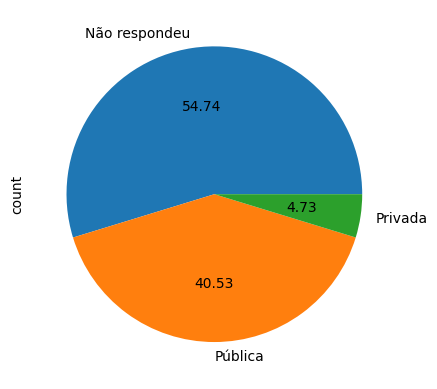

In [59]:
(
    df.TP_ESCOLA.map({1:'Não respondeu', 2:'Pública', 3:'Privada'})
    .value_counts()
    .plot(
        kind='pie',
        legend=False,
        autopct='%.2f'
    )
)

<Axes: xlabel='NU_NOTA_MT', ylabel='NU_NOTA_CN'>

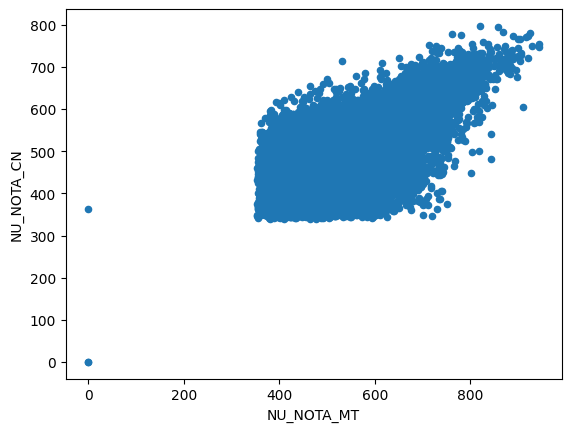

In [61]:
df.plot(kind='scatter', x='NU_NOTA_MT', y='NU_NOTA_CN')

<Axes: ylabel='Frequency'>

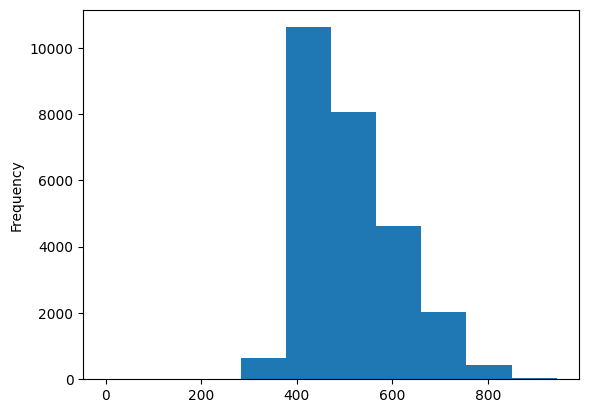

In [62]:
df.NU_NOTA_MT.plot(kind='hist')

<Axes: >

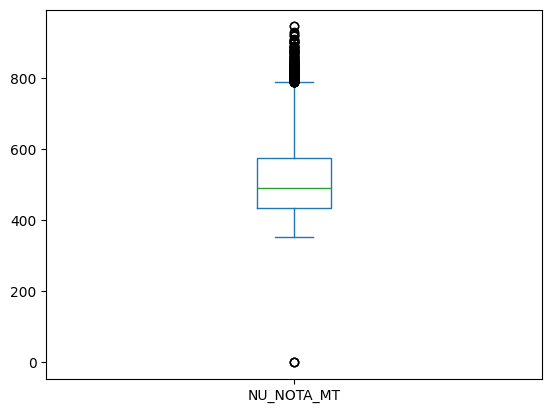

In [63]:
df.NU_NOTA_MT.plot(kind='box')

<Axes: >

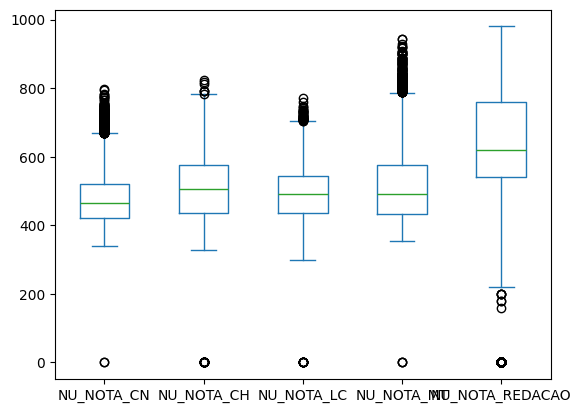

In [64]:
df[provas].plot(kind='box')

<Axes: ylabel='Density'>

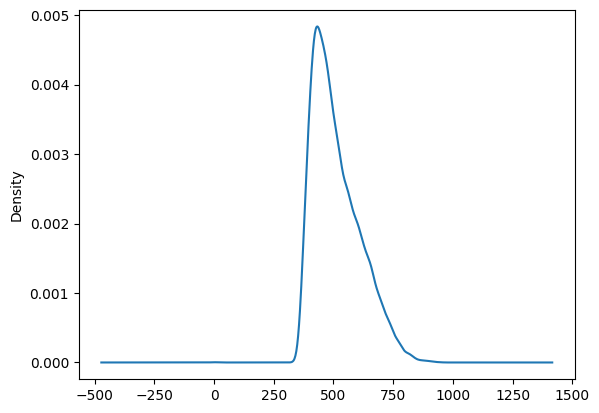

In [65]:
df.NU_NOTA_MT.plot(kind='kde')

/tmp/ipykernel_1916/2922544828.py:4: FutureWarning: The provided callable <function mean at 0x7c52301dff60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg({'NU_NOTA_MT':np.mean})


<Axes: title={'center': 'Nota média em matemática por municípios'}, xlabel='Município', ylabel='Média em matemática'>

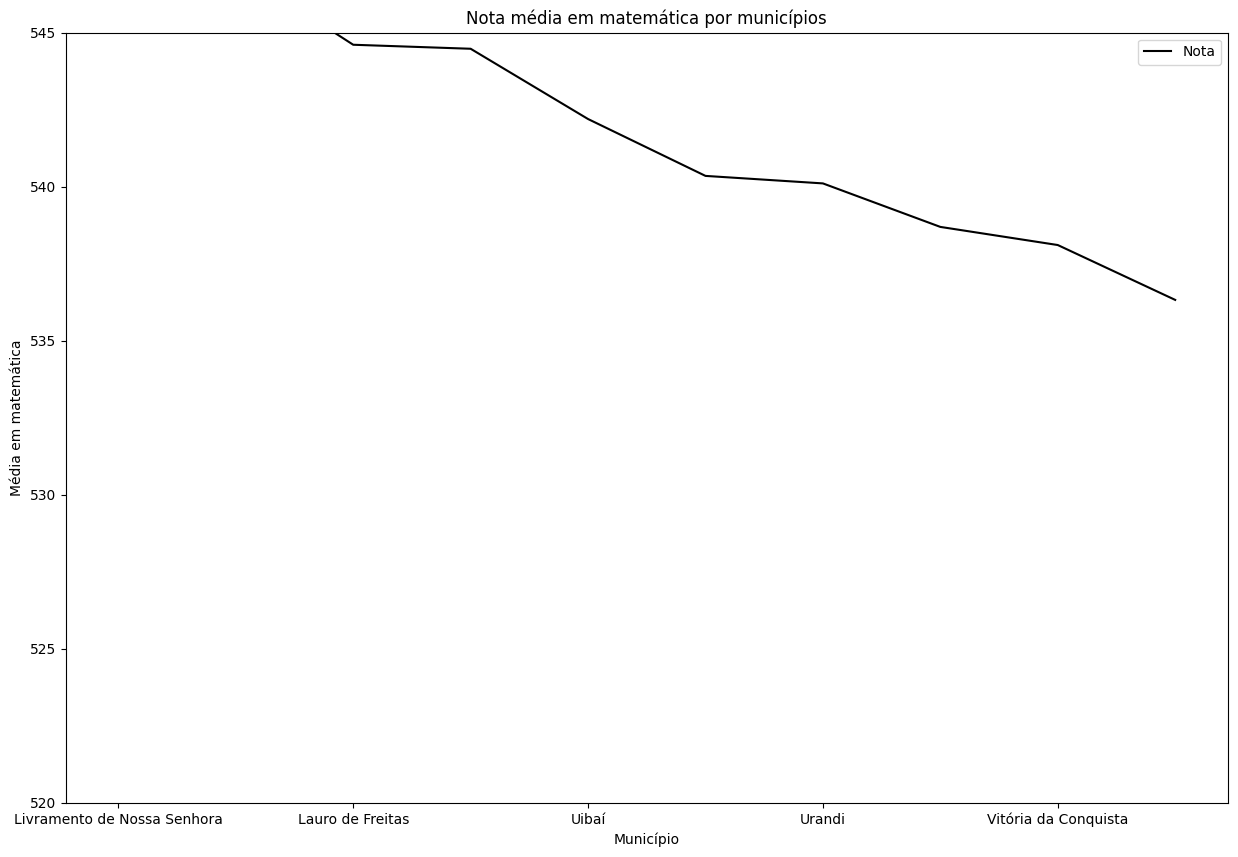

In [68]:
(
    df.
    groupby(by=['NO_MUNICIPIO_PROVA'])
    .agg({'NU_NOTA_MT':np.mean})
    .reset_index()
    .rename(columns = {'NU_NOTA_MT':'Nota', 'NO_MUNICIPIO_PROVA':'Município'})
    .nlargest(n=10, columns='Nota')
    .plot(
        x = 'Município',
        y = 'Nota',
        figsize = (15, 10),
        color = 'k',
        ylabel = 'Média em matemática',
        title = 'Nota média em matemática por municípios',
        ylim = [520, 545]
    )
)

Ordenação

Em alguns casos precisamos ordenar os dados por alguma coluna ou conjunto de colunas. No Pandas podemos utilizar a função `.sort_values()`.

In [69]:
provas = df.columns[(df.columns.str.contains('NOTA')) & (~df.columns.str.contains('COMP'))].tolist()
idCandidato = ['NU_INSCRICAO']

In [71]:
df_subset = df[idCandidato+provas].sample(n=10, random_state = 9999)

In [72]:
#Ordena o dataset emordm descrecente
df_subset.sort_values(by=['NU_NOTA_MT'], ascending=False)

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
17110,210051720437,603.5,656.3,618.7,756.8,900.0
23554,210054118872,491.5,568.4,555.1,601.8,840.0
23865,210052773967,467.3,499.8,459.0,529.0,560.0
5384,210053274807,475.3,598.0,543.0,525.1,600.0
23581,210052820776,408.7,483.3,520.8,491.5,540.0
11154,210054126328,530.5,565.1,494.1,444.6,500.0
13695,210051373228,410.1,351.0,427.6,382.4,600.0
26272,210051329159,NaN,NaN,NaN,NaN,NaN
14637,210054265653,NaN,NaN,NaN,NaN,NaN
15078,210051571208,NaN,NaN,NaN,NaN,NaN


In [73]:
#Ordena o dataset em ordem crescente
df_subset.sort_values(by=['NU_NOTA_MT'], ascending=True)

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
13695,210051373228,410.1,351.0,427.6,382.4,600.0
11154,210054126328,530.5,565.1,494.1,444.6,500.0
23581,210052820776,408.7,483.3,520.8,491.5,540.0
5384,210053274807,475.3,598.0,543.0,525.1,600.0
23865,210052773967,467.3,499.8,459.0,529.0,560.0
23554,210054118872,491.5,568.4,555.1,601.8,840.0
17110,210051720437,603.5,656.3,618.7,756.8,900.0
26272,210051329159,NaN,NaN,NaN,NaN,NaN
14637,210054265653,NaN,NaN,NaN,NaN,NaN
15078,210051571208,NaN,NaN,NaN,NaN,NaN
